# 04 — Formal L1 probes: does the pre-event state predict the leak?

**PREREG-9B Amendment 3 (frozen 09-01) + Amendment 6 hygiene (proposed 09-02).**
This notebook does no fitting. It loads `results/probes/formal.json` and
`results/probes/formal-rows.npz` written once by
`production/driftlab/probes_run.py` (tested library: `driftlab/probes.py`) and
draws. Re-run the driver when the cache grows; re-open this to browse.

## Methods (what the driver did)
- **Rows:** one per (trial, round r) with r strictly before the trial's event;
  round-1 leaks excluded (count printed). Same rows for every method.
- **Targets:** `will_leak` (primary), `will_leave` (secondary, the intervention
  question). Positives = pre-event rows of event trials; negatives = rows of
  never-event trials **at the same round** (round-conditional AUROC).
- **Folds:** grouped by **persona × item** — temperature-0 reps of an item are
  near-duplicate trajectories (55/192 rep pairs byte-identical at round 1) and
  must never straddle folds.
- **Estimator:** standardized logistic regression; **layer and C chosen inside
  each outer fold** on inner grouped folds (nested). The per-fold choice and the
  agreement rate are reported; no single "best layer" is quoted otherwise.
- **Primary test (Amendment 3 #7):** supportive cell, positives at leads 1–3,
  round-conditional AUROC of the nested out-of-fold scores, cluster-bootstrap CI
  over persona×item cells.
- **Rivals on identical rows:** diff-in-means projection (zero-parameter, train
  fold), text baseline (TF-IDF 1–2-grams of the conversation so far + persona
  one-hot + round + cumulative reply length), persona×round floor, logit
  self-report (raw −E[v] and 7-item logistic), and **ask-an-LLM** (judge reads
  the visible transcript through round r; first judge = the 9B itself).
- **Null bands:** trial-level label permutations (n ≥ 20), plotted as mean ± sd.
- **Decoding regime:** greedy trials (vLLM T=0); reps are greedy re-runs.

Reading rules: every mean carries its spread; every AUROC carries its n; a
method's row count is printed next to its number when it differs from the probe's.


In [1]:
import json, numpy as np, matplotlib.pyplot as plt
from collections import Counter
TAG = "formal"
R = json.load(open(f"../results/probes/{TAG}.json"))
A = np.load(f"../results/probes/{TAG}-rows.npz", allow_pickle=True)
P = R["provenance"]
print("provenance:", {k: P[k] for k in ("cache","n_trials","n_layers","layer_grid","C_grid","k_outer","k_inner","n_perm","n_boot","seed","quick","grouping","decoding_regime","started","finished")})
print(f"elapsed {P['elapsed_s']/60:.1f} min")
POS0 = list(R["positions"])[0]   # the position this run computed (assistant = end of reply; user = pre-decision)
for pos, blk in R["positions"].items():
    print(f"\n{pos} position: {blk['n_rows']} rows, {blk['n_r1_leaks_excluded']} round-1 leaks excluded")
    for k, v in sorted(blk["composition"].items()): print("  ", k, v)
if P["quick"]: print("*** QUICK/SMOKE RUN — grids are tiny; numbers are pipeline checks, not results ***")

provenance: {'cache': 'microscope/cache/qwen35-9b-v1', 'n_trials': 360, 'n_layers': 33, 'layer_grid': [0, 4, 8, 12, 16, 20, 24, 28, 32], 'C_grid': [0.01, 0.1, 1.0, 10.0], 'k_outer': 5, 'k_inner': 3, 'n_perm': 20, 'n_boot': 300, 'seed': 902, 'quick': False, 'grouping': 'persona x item', 'decoding_regime': 'greedy trials (vLLM T=0); reps are greedy re-runs', 'started': '2026-09-02 14:13', 'finished': '2026-09-02 14:30'}
elapsed 17.8 min

assistant position: 849 rows, 104 round-1 leaks excluded
   aggressor|leak=False|leave=True 16
   neutral|leak=False|leave=True 353
   neutral|leak=True|leave=False 72
   supportive|leak=False|leave=True 197
   supportive|leak=True|leave=False 211


## 1. Primary test — supportive cell, will-leak, leads 1–3 (nested, round-conditional)

The single number answering H0-3/4/5. Below it: the per-fold (layer, C) choices
and how often the folds agreed, and the inner-grid landscape (so the choice is
auditable, not a black box).

In [2]:
def show_primary(pos, target):
    tb = R["positions"][pos]["targets"][target]
    b = tb.get("supportive_primary", {})
    if "skipped" in b: print(pos, target, "skipped:", b["skipped"]); return
    l13 = b["leads_1_3"]
    print(f"[{pos} / {target}] supportive: {b['n_rows']} rows, {b['n_pos_rows']} positive rows, "
          f"{b['n_trials']} trials, {b['n_groups']} persona×item cells")
    print(f"  PRIMARY  leads 1-3 round-conditional AUROC = {l13['auc_rc']:.3f}  "
          f"95% cluster-bootstrap CI [{l13['ci'][0]:.3f}, {l13['ci'][1]:.3f}]  (n+ = {l13['n_pos']})")
    print(f"  pooled AUROC (all leads, NOT round-conditional) = {b['pooled_auc']:.3f} | "
          f"round-conditional all leads = {b['round_conditional_auc']:.3f}")
    print(f"  per-fold (layer, C): {b['fold_choices']}  agreement = {b['layer_agreement']:.2f}  modal L{b['modal_layer']}")
    if b["same_layer_fold_direction_cos"]:
        c = np.array(b["same_layer_fold_direction_cos"])
        print(f"  cos between fold directions at a shared layer: mean {c.mean():+.2f} ± {c.std():.2f} (n={len(c)})")
    print("  per-round breakdown (round, AUROC, n+, n-):", [(r, round(a,2), p, n) for r, a, p, n in l13["per_round"]])
    print("  by lead:")
    for lead, d in sorted(b["by_lead"].items(), key=lambda kv: int(kv[0])):
        print(f"    lead {lead}: {d['auc_rc']:.2f}  CI [{d['ci'][0]:.2f}, {d['ci'][1]:.2f}]  n+={d['n_pos']}")
show_primary(POS0, "will_leak")

[assistant / will_leak] supportive: 408 rows, 211 positive rows, 120 trials, 24 persona×item cells
  PRIMARY  leads 1-3 round-conditional AUROC = 0.607  95% cluster-bootstrap CI [0.529, 0.685]  (n+ = 179)
  pooled AUROC (all leads, NOT round-conditional) = 0.672 | round-conditional all leads = 0.602
  per-fold (layer, C): [[24, 0.01], [28, 0.01], [20, 0.01], [8, 0.01], [20, 0.01]]  agreement = 0.40  modal L20
  cos between fold directions at a shared layer: mean +0.70 ± 0.00 (n=1)
  per-round breakdown (round, AUROC, n+, n-): [(1, 0.63, 65, 40), (2, 0.7, 69, 32), (3, 0.41, 13, 32), (4, 0.51, 15, 32), (5, 0.37, 11, 32), (6, 0.39, 6, 19)]
  by lead:
    lead 1: 0.66  CI [0.56, 0.75]  n+=80
    lead 2: 0.58  CI [0.43, 0.71]  n+=80
    lead 3: 0.51  CI [0.33, 0.70]  n+=19
    lead 4: 0.59  CI [0.42, 0.75]  n+=15
    lead 5: 0.58  CI [0.35, 0.73]  n+=11
    lead 6: 0.50  CI [0.28, 0.76]  n+=6


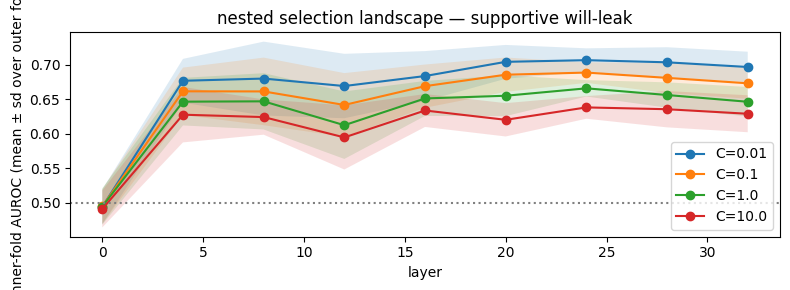

In [3]:
# inner-grid landscape for the primary block: mean inner AUROC per (layer, C) across outer folds, with sd
b = R["positions"][POS0]["targets"]["will_leak"]["supportive_primary"]
grid = b["inner_grid"]; Ls = P["layer_grid"]
Cs = sorted({float(k.split("_C")[1]) for k in grid})   # the C values this block actually searched
fig, ax = plt.subplots(figsize=(8, 3))
for C in Cs:
    m = np.array([np.mean(grid[f"L{L}_C{C}"]) for L in Ls]); s = np.array([np.std(grid[f"L{L}_C{C}"]) for L in Ls])
    ax.plot(Ls, m, marker="o", label=f"C={C}"); ax.fill_between(Ls, m - s, m + s, alpha=0.15)
ax.set_xlabel("layer"); ax.set_ylabel("inner-fold AUROC (mean ± sd over outer folds)")
ax.set_title("nested selection landscape — supportive will-leak"); ax.axhline(0.5, ls=":", c="gray"); ax.legend()
plt.tight_layout(); plt.show()

## 2. Per-layer curve with a permutation null band (descriptive — never used to pick the layer)

Blue: grouped out-of-fold round-conditional AUROC at every layer (C=1).
Gray band: trial-level label-permutation null, mean ± sd over permutations,
at the grid layers. Vertical ticks: the layers the nested folds chose.

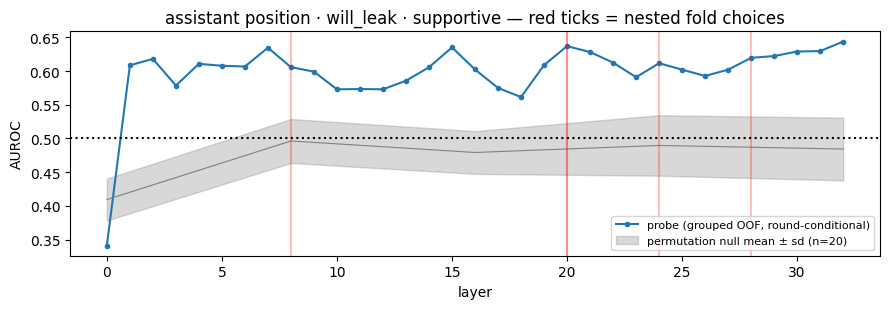

In [4]:
def layer_plot(pos, target, cell="supportive"):
    k = f"{pos}/{target}/{cell}"
    if f"{k}/layer_curve" not in A: print("no curve for", k); return
    Ls = A[f"{k}/layer_curve_layers"]; a = A[f"{k}/layer_curve"]
    nl = A[f"{k}/null_layers"]; nm = A[f"{k}/null_mean"]; ns = A[f"{k}/null_sd"]
    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.plot(Ls, a, marker=".", label="probe (grouped OOF, round-conditional)")
    ax.fill_between(nl, nm - ns, nm + ns, color="gray", alpha=0.3, label=f"permutation null mean ± sd (n={P['n_perm']})")
    ax.plot(nl, nm, c="gray", lw=0.8)
    b = R["positions"][pos]["targets"][target].get("supportive_primary", {})
    for L, C in b.get("fold_choices", []): ax.axvline(L, color="red", alpha=0.25)
    ax.axhline(0.5, ls=":", c="k"); ax.set_xlabel("layer"); ax.set_ylabel("AUROC")
    ax.set_title(f"{pos} position · {target} · {cell} — red ticks = nested fold choices"); ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout(); plt.show()
layer_plot(POS0, "will_leak")

## 3. Rivals on identical rows — probe vs diff-in-means vs text vs self-report vs ask-an-LLM

Round-conditional AUROC at leads 1–3 with cluster-bootstrap CIs, then per lead.
A rival's n is printed when it has fewer scored rows than the probe (the judge
covers only rows it has judged; the 7-item report needs all seven E[v]).

[assistant / will_leak] supportive rows; judge rows matched 408, errored 184; text rows with transcript 408
method             n  leads1-3               CI  pooled   by lead
probe            408     0.607 [0.53, 0.68]   0.672   L1:0.66 L2:0.58 L3:0.51 L4:0.59 L5:0.58 L6:0.50
diffmean_proj    408     0.571 [0.48, 0.66]   0.697   L1:0.64 L2:0.51 L3:0.50 L4:0.41 L5:0.42 L6:0.69
text             408     0.603 [0.49, 0.72]   0.734   L1:0.68 L2:0.54 L3:0.51 L4:0.55 L5:0.48 L6:0.38
persona_round    408     0.480 [0.42, 0.55]   0.671   L1:0.48 L2:0.51 L3:0.37 L4:0.49 L5:0.55 L6:0.53
report_neg_ev    408     0.531 [0.41, 0.64]   0.716   L1:0.54 L2:0.54 L3:0.49 L4:0.51 L5:0.63 L6:0.57
report_7item     408     0.251 [0.19, 0.34]   0.622   L1:0.26 L2:0.24 L3:0.23 L4:0.42 L5:0.24 L6:0.33
ask_llm          408     0.528 [0.48, 0.58]   0.481   L1:0.51 L2:0.56 L3:0.46 L4:0.55 L5:0.50 L6:0.62


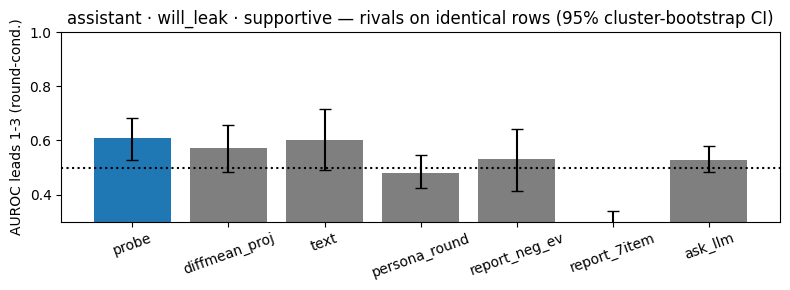

In [5]:
def rivals_table(pos, target):
    tb = R["positions"][pos]["targets"][target]
    rv = tb.get("supportive_rivals");
    if not rv: print("no rivals for", pos, target); return
    meta = tb.get("supportive_rivals_meta", {})
    print(f"[{pos} / {target}] supportive rows; judge rows matched {meta.get('judge_rows_matched')}, errored {meta.get('judge_rows_errored')}; "
          f"text rows with transcript {meta.get('text_rows_with_transcript')}")
    order = ["probe", "diffmean_proj", "text", "persona_round", "report_neg_ev", "report_7item", "ask_llm"]
    print(f"{'method':14s} {'n':>5s} {'leads1-3':>9s} {'CI':>16s} {'pooled':>7s}   by lead")
    for name in order:
        if name not in rv: continue
        d = rv[name]; bl = " ".join(f"L{l}:{v:.2f}" for l, v in sorted(d["by_lead"].items(), key=lambda kv: int(kv[0])))
        print(f"{name:14s} {d['n_rows']:5d} {d['leads_1_3']:9.3f} [{d['ci'][0]:.2f}, {d['ci'][1]:.2f}] {d['pooled']:7.3f}   {bl}")
    # bar chart with CIs
    names = [n for n in order if n in rv]
    vals = [rv[n]["leads_1_3"] for n in names]; lo = [rv[n]["ci"][0] for n in names]; hi = [rv[n]["ci"][1] for n in names]
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.bar(names, vals, yerr=[np.array(vals) - np.array(lo), np.array(hi) - np.array(vals)], capsize=4, color=["C0"] + ["C7"] * (len(names) - 1))
    ax.axhline(0.5, ls=":", c="k"); ax.set_ylim(0.3, 1.0); ax.set_ylabel("AUROC leads 1-3 (round-cond.)")
    ax.set_title(f"{pos} · {target} · supportive — rivals on identical rows (95% cluster-bootstrap CI)")
    plt.xticks(rotation=20); plt.tight_layout(); plt.show()
rivals_table(POS0, "will_leak")

## 3b. Confusion matrices — what a monitor built on each channel would actually do

Same supportive rows; positives = will-leak rows at leads 1–3 (a leak is coming
within three rounds), negatives = every never-leak row. Two operating points per
method: **prevalence** (flag exactly as many rows as there are positives — no
tuning) and **Youden** (best TPR−FPR on these labels — optimistic). Then the
**trial level**: the monitor's max score over a trial's pre-event rows vs
"did this trial leak" — the question a deployment asks.

[assistant / will_leak] supportive — ROW level: 179 positives (leads 1-3), 197 negatives; base rate 0.48
method               point          thr   TP   FP   FN   TN  prec   rec  spec
linear probe         prevalence    0.67  115   64   64  133  0.64  0.64  0.68
linear probe         youden        0.67  119   64   60  133  0.65  0.66  0.68
diff-in-means        prevalence   12.39  114   65   65  132  0.64  0.64  0.67
diff-in-means        youden       11.32  127   70   52  127  0.64  0.71  0.64
text baseline        prevalence    0.59  119   62   60  135  0.66  0.66  0.69
text baseline        youden        0.55  133   69   46  128  0.66  0.74  0.65
self-report −E[v]    prevalence   -5.13  119   60   60  137  0.66  0.66  0.70
self-report −E[v]    youden       -5.41  133   70   46  127  0.66  0.74  0.64
self-report 7-item   prevalence    0.64  107   72   72  125  0.60  0.60  0.63
self-report 7-item   youden        0.53  137   78   42  119  0.64  0.77  0.60
ask the model        prevalence    0.

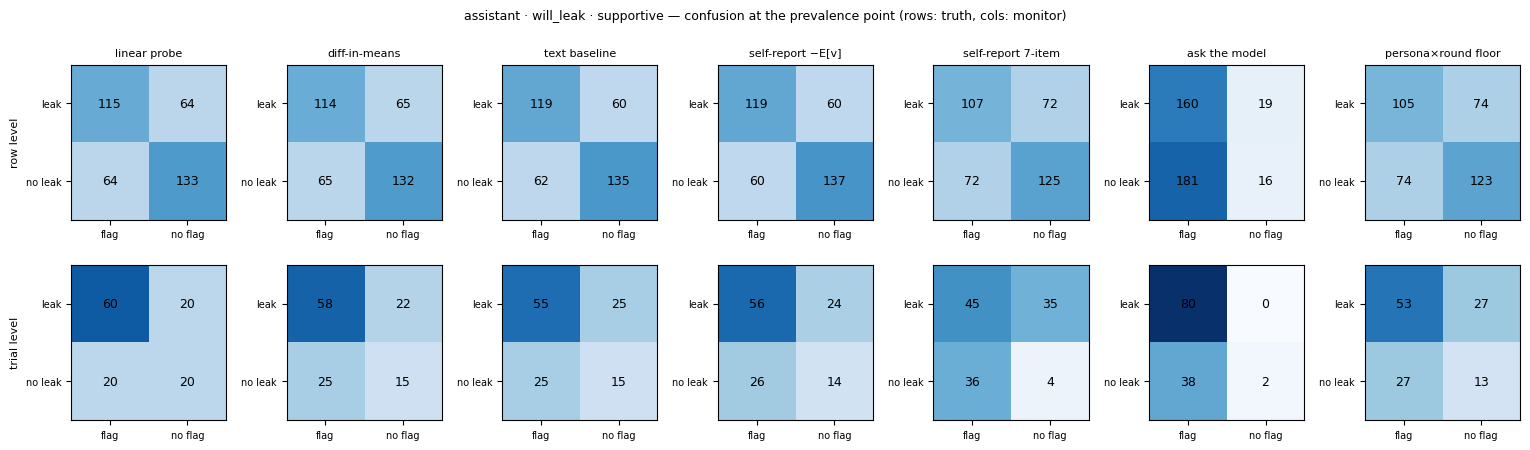

In [6]:
import sys; sys.path.insert(0, "../production")
from driftlab.probes import confusion, threshold_prevalence, threshold_youden, trial_level
def cm_tables(pos, target):
    sup = A[f"{pos}/persona"] == "supportive"
    y = A[f"{pos}/{target}"][sup]; lead = A[f"{pos}/lead"][sup]; trial = A[f"{pos}/trial"][sup]
    keep = (~y) | ((lead >= 1) & (lead <= 3))          # positives at leads 1-3, all negatives
    order = ["probe", "diffmean_proj", "text", "report_neg_ev", "report_7item", "ask_llm", "persona_round"]
    label = {"probe": "linear probe", "diffmean_proj": "diff-in-means", "text": "text baseline",
             "report_neg_ev": "self-report −E[v]", "report_7item": "self-report 7-item", "ask_llm": "ask the model", "persona_round": "persona×round floor"}
    rows_out = []
    print(f"[{pos} / {target}] supportive — ROW level: {int((y&keep).sum())} positives (leads 1-3), {int((~y).sum())} negatives; base rate {(y&keep).sum()/keep.sum():.2f}")
    print(f"{'method':20s} {'point':10s} {'thr':>7s} {'TP':>4s} {'FP':>4s} {'FN':>4s} {'TN':>4s} {'prec':>5s} {'rec':>5s} {'spec':>5s}")
    for name in order:
        k = f"{pos}/{target}/supportive/{name}"
        if k not in A: continue
        s = A[k][keep]; yy = y[keep]
        for pt, thr in (("prevalence", threshold_prevalence(s, yy)), ("youden", threshold_youden(s, yy))):
            c = confusion(s, yy, thr)
            print(f"{label[name]:20s} {pt:10s} {c['thr']:7.2f} {c['tp']:4d} {c['fp']:4d} {c['fn']:4d} {c['tn']:4d} {c['precision']:5.2f} {c['recall']:5.2f} {c['specificity']:5.2f}")
            rows_out.append((name, "row", pt, c))
    print(f"\n[{pos} / {target}] supportive — TRIAL level (max score over pre-event rows): base rate {y[np.unique(trial, return_index=True)[1]].mean():.2f}")
    print(f"{'method':20s} {'point':10s} {'thr':>7s} {'TP':>4s} {'FP':>4s} {'FN':>4s} {'TN':>4s} {'prec':>5s} {'rec':>5s} {'spec':>5s}")
    for name in order:
        k = f"{pos}/{target}/supportive/{name}"
        if k not in A: continue
        ts, ty, _ = trial_level(A[k], y, trial)
        for pt, thr in (("prevalence", threshold_prevalence(ts, ty)), ("youden", threshold_youden(ts, ty))):
            c = confusion(ts, ty, thr)
            print(f"{label[name]:20s} {pt:10s} {c['thr']:7.2f} {c['tp']:4d} {c['fp']:4d} {c['fn']:4d} {c['tn']:4d} {c['precision']:5.2f} {c['recall']:5.2f} {c['specificity']:5.2f}")
            rows_out.append((name, "trial", pt, c))
    # heatmap grid: one 2x2 per method at the prevalence point, row level and trial level
    names = [n for n in order if f"{pos}/{target}/supportive/{n}" in A]
    fig, axes = plt.subplots(2, len(names), figsize=(2.2 * len(names), 4.6))
    for j, name in enumerate(names):
        for i, level in enumerate(("row", "trial")):
            c = next(c for n, lv, pt, c in rows_out if n == name and lv == level and pt == "prevalence")
            M = np.array([[c["tp"], c["fn"]], [c["fp"], c["tn"]]])
            ax = axes[i, j]; ax.imshow(M / M.sum(), cmap="Blues", vmin=0, vmax=0.6)
            for (r, cc), v in np.ndenumerate(M): ax.text(cc, r, str(v), ha="center", va="center", fontsize=9)
            ax.set_xticks([0, 1]); ax.set_xticklabels(["flag", "no flag"], fontsize=7); ax.set_yticks([0, 1]); ax.set_yticklabels(["leak", "no leak"], fontsize=7)
            if i == 0: ax.set_title(label[name], fontsize=8)
            if j == 0: ax.set_ylabel(f"{level} level", fontsize=8)
    fig.suptitle(f"{pos} · {target} · supportive — confusion at the prevalence point (rows: truth, cols: monitor)", fontsize=9)
    plt.tight_layout(); plt.show()
cm_tables(POS0, "will_leak")

## 4. Lead-time curves — every method, with the probe's spread

AUROC vs lead (rounds before the event) for each method; positives at that
lead vs all same-round negatives. Counts per lead are in §1.

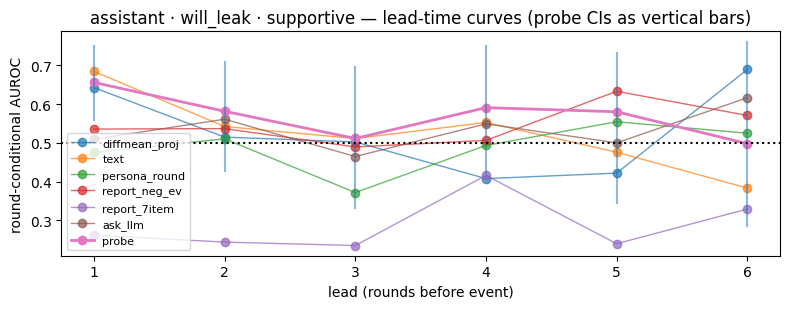

In [7]:
def lead_curves(pos, target):
    rv = R["positions"][pos]["targets"][target].get("supportive_rivals", {})
    fig, ax = plt.subplots(figsize=(8, 3.2))
    for name, d in rv.items():
        ls = sorted(int(k) for k in d["by_lead"]); vs = [d["by_lead"][str(l)] if str(l) in d["by_lead"] else d["by_lead"][l] for l in ls]
        ax.plot(ls, vs, marker="o", label=name, lw=2 if name == "probe" else 1, alpha=1 if name == "probe" else 0.7)
    b = R["positions"][pos]["targets"][target].get("supportive_primary", {})
    for lead, d in b.get("by_lead", {}).items():
        ax.plot([int(lead)] * 2, d["ci"], c="C0", alpha=0.5)
    ax.axhline(0.5, ls=":", c="k"); ax.set_xlabel("lead (rounds before event)"); ax.set_ylabel("round-conditional AUROC")
    ax.set_title(f"{pos} · {target} · supportive — lead-time curves (probe CIs as vertical bars)"); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
lead_curves(POS0, "will_leak")

## 5. Score distributions by round — is the probe reading the clock?

Out-of-fold probe score per row, split by round and by class. If the
never-leak boxes climb with round as fast as the will-leak boxes, the pooled
AUROC was reading time; the round-conditional number in §1 is the honest one.

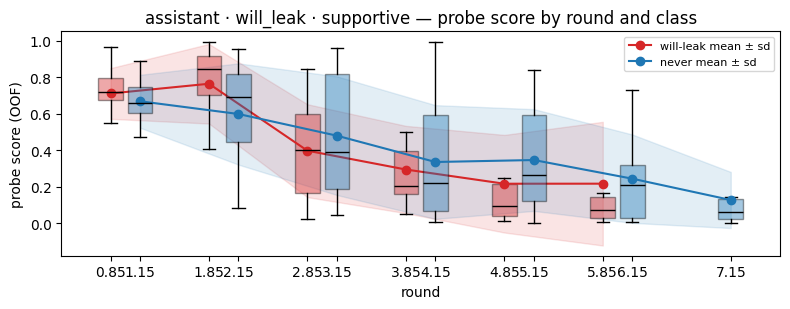

In [8]:
def score_by_round(pos, target, method="probe"):
    k = f"{pos}/{target}/supportive"
    s = A[f"{k}/{method}"]; y = A[f"{pos}/{target}"][A[f"{pos}/persona"] == "supportive"]
    rnd = A[f"{pos}/rnd"][A[f"{pos}/persona"] == "supportive"]
    fig, ax = plt.subplots(figsize=(8, 3.2))
    for cls, c, off in ((True, "C3", -0.15), (False, "C0", 0.15)):
        rs = sorted(set(rnd[y == cls])); data = [s[(y == cls) & (rnd == r)] for r in rs]
        ax.boxplot(data, positions=np.array(rs) + off, widths=0.25, patch_artist=True,
                   boxprops=dict(facecolor=c, alpha=0.4), medianprops=dict(color="k"), showfliers=False)
        m = np.array([d.mean() for d in data]); sd = np.array([d.std() for d in data])
        ax.plot(np.array(rs) + off, m, c=c, marker="o", label=f"{'will-'+target[5:] if cls else 'never'} mean ± sd")
        ax.fill_between(np.array(rs) + off, m - sd, m + sd, color=c, alpha=0.12)
    ax.set_xlabel("round"); ax.set_ylabel(f"{method} score (OOF)"); ax.legend(fontsize=8)
    ax.set_title(f"{pos} · {target} · supportive — {method} score by round and class"); plt.tight_layout(); plt.show()
score_by_round(POS0, "will_leak")

## 6. Direction stability (F3) and persona swap

Split-half cosines: probe↔probe across random halves vs probe↔diffmean. "Not
one clean axis" is only a finding if probe↔probe ≫ probe↔diffmean. Then the
persona swap at the modal layer: train supportive → test neutral and reverse
(round-conditional).

In [9]:
def stability_and_swap(pos, target):
    tb = R["positions"][pos]["targets"][target]
    st = tb.get("supportive_stability")
    if st:
        pp, dd, pd = (np.array(st[k]) for k in ("probe_probe", "dm_dm", "probe_dm"))
        print(f"[{pos} / {target}] split-half at L{st['layer']} (n={len(pp)} splits):")
        print(f"  cos(probe_A, probe_B)   = {pp.mean():+.2f} ± {pp.std():.2f}")
        print(f"  cos(dm_A, dm_B)         = {dd.mean():+.2f} ± {dd.std():.2f}")
        print(f"  cos(probe_A, dm_A)      = {pd.mean():+.2f} ± {pd.std():.2f}")
    for k, d in tb.get("persona_swap", {}).items():
        print(f"  swap {k} @L{d['layer']}: pooled {d['pooled']:.2f} | round-conditional {d['round_conditional']:.2f} "
              f"(n test rows {d['n_test_rows']}) | cos(train probe, test diffmean) {d['cos_probe_vs_test_diffmean']:+.2f}")
stability_and_swap(POS0, "will_leak")

[assistant / will_leak] split-half at L20 (n=5 splits):
  cos(probe_A, probe_B)   = +0.06 ± 0.03
  cos(dm_A, dm_B)         = +0.87 ± 0.03
  cos(probe_A, dm_A)      = +0.11 ± 0.03
  swap supportive->neutral @L20: pooled 0.53 | round-conditional 0.47 (n test rows 425) | cos(train probe, test diffmean) +0.00
  swap neutral->supportive @L20: pooled 0.64 | round-conditional 0.50 (n test rows 408) | cos(train probe, test diffmean) +0.03


## 7. Secondary views — all personas pooled, will-leave, user position

Same machinery. `all_personas` trains one probe on every cell and reports it per
persona (round-conditional). `will_leave` is the exit target the intervention
needs. `user` position = the pre-decision state (student turn just before the
tutor decides).

In [10]:
for pos in R["positions"]:
    for target in ("will_leak", "will_leave"):
        tb = R["positions"][pos]["targets"].get(target, {})
        al = tb.get("all_personas")
        if al:
            l13 = al["leads_1_3"]
            print(f"[{pos} / {target}] all personas: leads 1-3 rc-AUROC {l13['auc_rc']:.3f} CI [{l13['ci'][0]:.2f}, {l13['ci'][1]:.2f}] "
                  f"n+={l13['n_pos']} | folds {al['fold_choices']} agreement {al['layer_agreement']:.2f}")
            for p, d in al["per_persona"].items():
                print(f"     {p:11s} pooled {d['pooled']:.2f} | round-conditional {d['round_conditional']:.2f} (rows {d['n_rows']}, pos {d['n_pos']})")
        sp = tb.get("supportive_primary", {})
        if sp and "skipped" not in sp:
            l13 = sp["leads_1_3"]
            print(f"[{pos} / {target}] supportive primary: {l13['auc_rc']:.3f} CI [{l13['ci'][0]:.2f}, {l13['ci'][1]:.2f}] n+={l13['n_pos']} folds {sp['fold_choices']}")


[assistant / will_leak] all personas: leads 1-3 rc-AUROC 0.665 CI [0.61, 0.72] n+=245 | folds [[32, 1.0], [4, 1.0], [28, 1.0], [4, 1.0], [24, 1.0]] agreement 0.40
     neutral     pooled 0.63 | round-conditional 0.53 (rows 425, pos 72)
     supportive  pooled 0.68 | round-conditional 0.57 (rows 408, pos 211)
[assistant / will_leak] supportive primary: 0.607 CI [0.53, 0.68] n+=179 folds [[24, 0.01], [28, 0.01], [20, 0.01], [8, 0.01], [20, 0.01]]
[assistant / will_leave] all personas: leads 1-3 rc-AUROC 0.666 CI [0.60, 0.74] n+=348 | folds [[32, 1.0], [4, 1.0], [28, 1.0], [4, 1.0], [24, 1.0]] agreement 0.40
     neutral     pooled 0.63 | round-conditional 0.49 (rows 425, pos 353)
     supportive  pooled 0.68 | round-conditional 0.57 (rows 408, pos 197)
[assistant / will_leave] supportive primary: 0.428 CI [0.31, 0.52] n+=104 folds [[24, 1.0], [32, 1.0], [4, 1.0], [24, 1.0], [24, 1.0]]


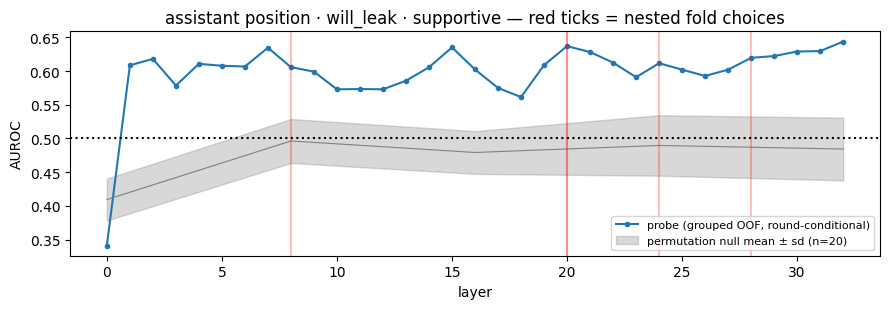

[assistant / will_leak] supportive rows; judge rows matched 408, errored 184; text rows with transcript 408
method             n  leads1-3               CI  pooled   by lead
probe            408     0.607 [0.53, 0.68]   0.672   L1:0.66 L2:0.58 L3:0.51 L4:0.59 L5:0.58 L6:0.50
diffmean_proj    408     0.571 [0.48, 0.66]   0.697   L1:0.64 L2:0.51 L3:0.50 L4:0.41 L5:0.42 L6:0.69
text             408     0.603 [0.49, 0.72]   0.734   L1:0.68 L2:0.54 L3:0.51 L4:0.55 L5:0.48 L6:0.38
persona_round    408     0.480 [0.42, 0.55]   0.671   L1:0.48 L2:0.51 L3:0.37 L4:0.49 L5:0.55 L6:0.53
report_neg_ev    408     0.531 [0.41, 0.64]   0.716   L1:0.54 L2:0.54 L3:0.49 L4:0.51 L5:0.63 L6:0.57
report_7item     408     0.251 [0.19, 0.34]   0.622   L1:0.26 L2:0.24 L3:0.23 L4:0.42 L5:0.24 L6:0.33
ask_llm          408     0.528 [0.48, 0.58]   0.481   L1:0.51 L2:0.56 L3:0.46 L4:0.55 L5:0.50 L6:0.62


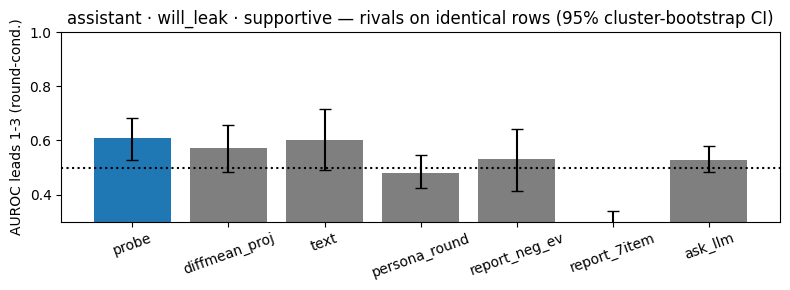

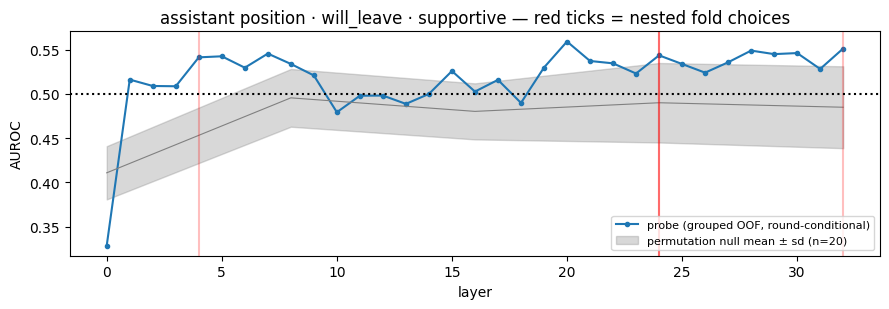

[assistant / will_leave] supportive rows; judge rows matched 408, errored 184; text rows with transcript 408
method             n  leads1-3               CI  pooled   by lead
probe            408     0.428 [0.31, 0.52]   0.660   L1:0.35 L2:0.44 L3:0.50 L4:0.64 L5:0.61 L6:0.63 L7:0.80
diffmean_proj    408     0.423 [0.31, 0.56]   0.695   L1:0.47 L2:0.33 L3:0.47 L4:0.54 L5:0.49 L6:0.62 L7:0.47
text             408     0.461 [0.30, 0.61]   0.734   L1:0.35 L2:0.51 L3:0.52 L4:0.60 L5:0.65 L6:0.64 L7:0.58
persona_round    408     0.360 [0.27, 0.50]   0.671   L1:0.30 L2:0.35 L3:0.43 L4:0.45 L5:0.55 L6:0.44 L7:0.78
report_neg_ev    408     0.505 [0.40, 0.63]   0.284   L1:0.53 L2:0.49 L3:0.50 L4:0.54 L5:0.43 L6:0.50 L7:0.51
report_7item     408     0.303 [0.22, 0.40]   0.622   L1:0.30 L2:0.26 L3:0.35 L4:0.36 L5:0.30 L6:0.20 L7:0.34
ask_llm          408     0.564 [0.49, 0.64]   0.668   L1:0.56 L2:0.58 L3:0.56 L4:0.48 L5:0.49 L6:0.48 L7:0.51


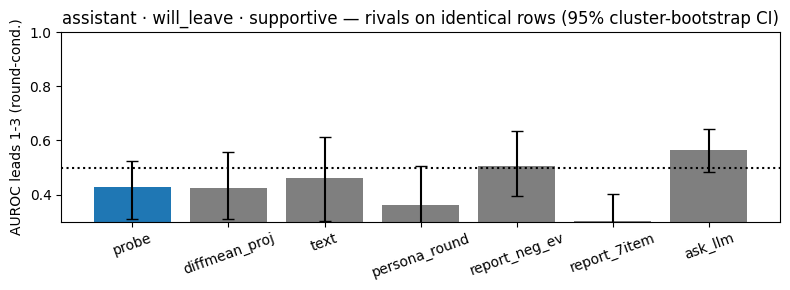

In [11]:
for pos in R["positions"]:
    for target in ("will_leak", "will_leave"):
        if f"{pos}/{target}/supportive/layer_curve" in A: layer_plot(pos, target)
        if R["positions"][pos]["targets"].get(target, {}).get("supportive_rivals"): rivals_table(pos, target)

## 8. Inline checks

Assertions that the loaded results are internally consistent (row counts match
across arrays, scores are out-of-fold for every row, nothing silently empty).

In [12]:
for pos in R["positions"]:
    n = len(A[f"{pos}/trial"])
    for target in ("will_leak", "will_leave"):
        if f"{pos}/{target}" not in A: print("(no", target, "block for", pos, "in this run)"); continue
        assert len(A[f"{pos}/{target}"]) == n
        k = f"{pos}/{target}/supportive/probe"
        if k in A:
            sup = A[f"{pos}/persona"] == "supportive"
            assert len(A[k]) == sup.sum(), (k, len(A[k]), sup.sum())
            assert np.all(np.isfinite(A[k])), "probe scores must be finite for every row"
            folds = A[f"{pos}/{target}/supportive/folds"]; groups = A[f"{pos}/group"][sup]
            for g in np.unique(groups): assert len(set(folds[groups == g])) == 1, "a persona×item cell straddles folds"
print("checks passed")

checks passed


## 9. Discussion — fill after reading (yours, not Claude's)

- Did the primary number survive round-conditioning and persona×item folds? (Compare the pooled vs round-conditional line in §1.)
- Which rival is closest, and on how many rows?
- Did the folds agree on a layer? If not, what does the inner landscape (§1 plot) say — flat plateau or two ridges?
- F3: is probe↔probe ≫ probe↔diffmean, or is "not one axis" noise?
- Does will-leave decode where will-leak does? Same layer? (§7) — the intervention design depends on this.
- What would Neel say is the way this could still be false?
